# Customer Segmentation using K-Means Clustering

## Objective
The goal of this project is to segment customers into distinct groups based on their purchasing behavior using unsupervised learning techniques.

## Dataset
Mall Customers Dataset (Kaggle)

## Tools
- Python
- Pandas, NumPy
- Scikit-learn
- Matplotlib, Seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("mall_customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

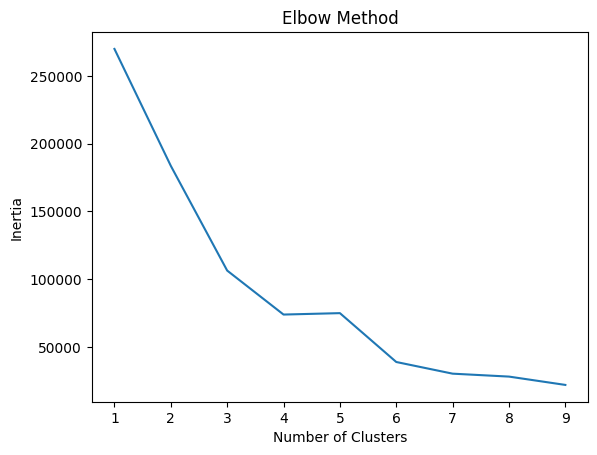

In [6]:
inertia = []

from sklearn.cluster import KMeans

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=5)
df["Cluster"] = kmeans.fit_predict(X)

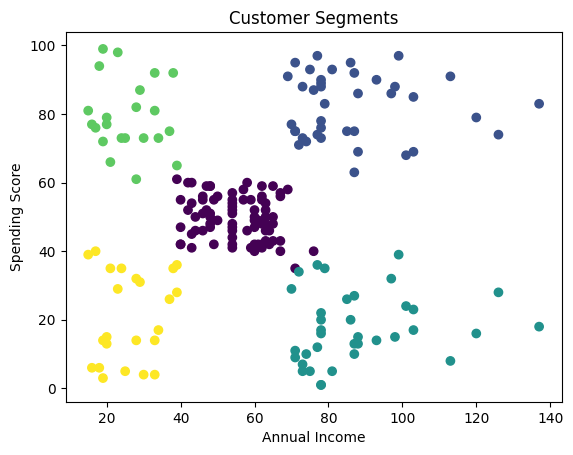

In [8]:
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

In [10]:
df.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,85.737500,42.937500,55.087500,49.712500
1,162.000000,32.692308,86.538462,82.128205
2,163.500000,40.666667,87.750000,17.583333
3,23.090909,25.272727,25.727273,79.363636
4,23.000000,45.217391,26.304348,20.913043


In [11]:
kmeans = KMeans(n_clusters=5)
df["Cluster"] = kmeans.fit_predict(X)

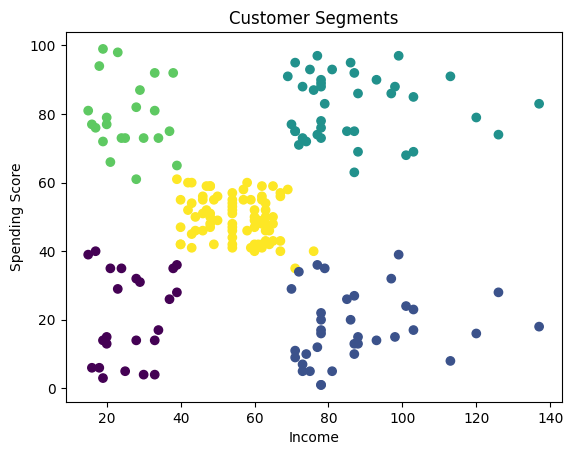

In [12]:
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

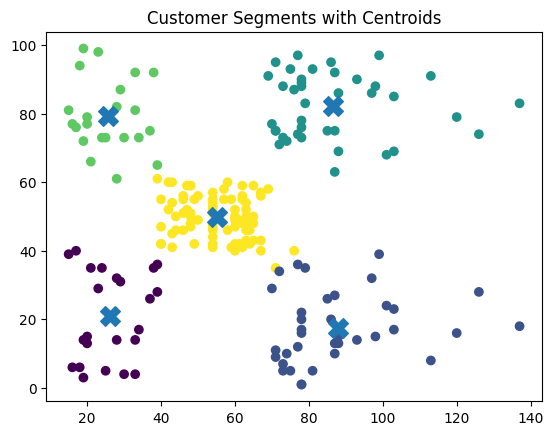

In [13]:
centers = kmeans.cluster_centers_

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.scatter(centers[:, 0], centers[:, 1], s=200, marker='X')

plt.title("Customer Segments with Centroids")
plt.show()

In [15]:
df.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,23.000000,45.217391,26.304348,20.913043
1,163.500000,40.666667,87.750000,17.583333
2,162.000000,32.692308,86.538462,82.128205
3,23.090909,25.272727,25.727273,79.363636
4,85.737500,42.937500,55.087500,49.712500


In [16]:
df["Segment"] = df["Cluster"].map({
    0: "High Value",
    1: "Low Value",
    2: "Mid Value",
    3: "Potential",
    4: "Risk"
})

In [ ]:
plt.savefig("clusters.png")

## Conclusion

- Customers were grouped into 5 segments using K-Means
- Each segment shows different income and spending behavior

## Key Insights
- High income + high spending → premium customers
- High income + low spending → upselling opportunity
- Low income + high spending → risky segment

## Business Impact
Helps companies:
- Target marketing campaigns
- Personalize offers
- Improve retention